# Cache-Aware String Sorting

This notebook starts the implementation workflow for the cache-aware algorithms from the report. It sets up the environment, imports the reusable Python modules, defines a first batch of datasets, and runs basic correctness checks.

## 1. Set Up Project Environment

In [1]:
from pathlib import Path
import sys
import platform

PROJECT_ROOT = Path.cwd().resolve()
while PROJECT_ROOT != PROJECT_ROOT.parent and not (PROJECT_ROOT / "Algorithms").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print(platform.python_version())
print(PROJECT_ROOT)

3.12.11
/root/IAE/AlgoEngineering


## 2. Import Dependencies

In [2]:
from dataclasses import asdict, dataclass
from typing import cast

from Algorithms import (
    benchmark_sort,
    benchmark_suite,
    burstsort,
    c_burstsort,
    cp_burstsort,
    cradix_sort,
    generate_dataset,
    generate_prefix_heavy_dataset,
    msd_radix_sort,
    multikey_quicksort,
    python_sort,
    summarize_benchmarks,
)


## 3. Define Core Configuration

In [3]:
CACHE_AWARE_ALGORITHMS = [
    ("python_sort", python_sort),
    ("multikey_quicksort", multikey_quicksort),
    ("msd_radix_sort", msd_radix_sort),
    ("cradix_sort", cradix_sort),
    ("burstsort", burstsort),
    ("c_burstsort", c_burstsort),
    ("cp_burstsort", cp_burstsort),
]

DATASET_LIBRARY = {
    "random": lambda count, seed: generate_dataset(count=count, seed=seed),
    "prefix_heavy": lambda count, seed: generate_prefix_heavy_dataset(count=count, seed=seed),
}


## 4. Implement Initial Data Structures

In [4]:
@dataclass(frozen=True)
class ExperimentCase:
    name: str
    dataset_name: str
    algorithm_name: str
    seed: int


EXPERIMENT_PLAN = [
    ExperimentCase(name="baseline-random", dataset_name="random", algorithm_name="python_sort", seed=0),
    ExperimentCase(name="prefix-heavy", dataset_name="prefix_heavy", algorithm_name="burstsort", seed=1),
]


## 5. Add Basic Validation Checks

In [5]:
sample = generate_prefix_heavy_dataset(count=32, seed=42)
expected = sorted(sample)

benchmark_rows = []
for algorithm_name, algorithm in CACHE_AWARE_ALGORITHMS:
    benchmark, output = benchmark_sort(algorithm_name, algorithm, sample)
    assert output == expected, f"{algorithm_name} produced an incorrect ordering"
    benchmark_rows.append(asdict(benchmark))

benchmark_rows

[{'algorithm': 'python_sort',
  'count': 32,
  'total_length': 399,
  'elapsed_seconds': 3.2040006772149354e-06,
  'sorted_correctly': True},
 {'algorithm': 'multikey_quicksort',
  'count': 32,
  'total_length': 399,
  'elapsed_seconds': 4.0175000322051346e-05,
  'sorted_correctly': True},
 {'algorithm': 'msd_radix_sort',
  'count': 32,
  'total_length': 399,
  'elapsed_seconds': 6.1031998484395444e-05,
  'sorted_correctly': True},
 {'algorithm': 'cradix_sort',
  'count': 32,
  'total_length': 399,
  'elapsed_seconds': 1.438799881725572e-05,
  'sorted_correctly': True},
 {'algorithm': 'burstsort',
  'count': 32,
  'total_length': 399,
  'elapsed_seconds': 1.1657000868581235e-05,
  'sorted_correctly': True},
 {'algorithm': 'c_burstsort',
  'count': 32,
  'total_length': 399,
  'elapsed_seconds': 8.999999408842996e-06,
  'sorted_correctly': True},
 {'algorithm': 'cp_burstsort',
  'count': 32,
  'total_length': 399,
  'elapsed_seconds': 1.2198001059005037e-05,
  'sorted_correctly': True}]

## 6. Run a Benchmark Sweep


In [6]:
benchmark_rows = benchmark_suite(
    CACHE_AWARE_ALGORITHMS,
    DATASET_LIBRARY,
    sizes=(32, 64, 128),
    seeds=(0, 1, 2),
)

benchmark_rows[:5]


[{'dataset': 'random',
  'count': 32,
  'seed': 0,
  'algorithm': 'python_sort',
  'elapsed_seconds': 3.668999852379784e-06,
  'sorted_correctly': True,
  'total_length': 403},
 {'dataset': 'random',
  'count': 32,
  'seed': 0,
  'algorithm': 'multikey_quicksort',
  'elapsed_seconds': 2.5704999643494375e-05,
  'sorted_correctly': True,
  'total_length': 403},
 {'dataset': 'random',
  'count': 32,
  'seed': 0,
  'algorithm': 'msd_radix_sort',
  'elapsed_seconds': 4.1740999222383834e-05,
  'sorted_correctly': True,
  'total_length': 403},
 {'dataset': 'random',
  'count': 32,
  'seed': 0,
  'algorithm': 'cradix_sort',
  'elapsed_seconds': 1.4884999472997151e-05,
  'sorted_correctly': True,
  'total_length': 403},
 {'dataset': 'random',
  'count': 32,
  'seed': 0,
  'algorithm': 'burstsort',
  'elapsed_seconds': 1.0478999683982693e-05,
  'sorted_correctly': True,
  'total_length': 403}]

## 7. Summarize Results


In [7]:
benchmark_summary = summarize_benchmarks(benchmark_rows)
benchmark_summary = sorted(benchmark_summary, key=lambda row: cast(float, row["mean_elapsed_seconds"]))
benchmark_summary


[{'algorithm': 'python_sort',
  'runs': 18,
  'mean_elapsed_seconds': 7.880222155007585e-06,
  'min_elapsed_seconds': 1.8600003386382014e-06,
  'max_elapsed_seconds': 3.355899934831541e-05,
  'all_sorted_correctly': True},
 {'algorithm': 'cp_burstsort',
  'runs': 18,
  'mean_elapsed_seconds': 2.4201833083578902e-05,
  'min_elapsed_seconds': 9.744000635691918e-06,
  'max_elapsed_seconds': 4.6265999117167667e-05,
  'all_sorted_correctly': True},
 {'algorithm': 'cradix_sort',
  'runs': 18,
  'mean_elapsed_seconds': 3.0354555444015812e-05,
  'min_elapsed_seconds': 1.1496000297483988e-05,
  'max_elapsed_seconds': 6.98709991411306e-05,
  'all_sorted_correctly': True},
 {'algorithm': 'burstsort',
  'runs': 18,
  'mean_elapsed_seconds': 3.713616721749228e-05,
  'min_elapsed_seconds': 5.714000508305617e-06,
  'max_elapsed_seconds': 9.440100075153168e-05,
  'all_sorted_correctly': True},
 {'algorithm': 'c_burstsort',
  'runs': 18,
  'mean_elapsed_seconds': 4.0575277833138695e-05,
  'min_elapsed_

## 8. Plot Comparisons


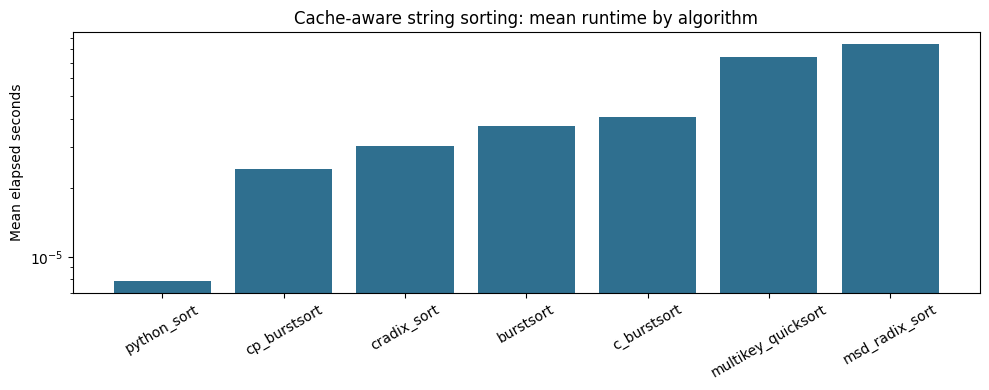

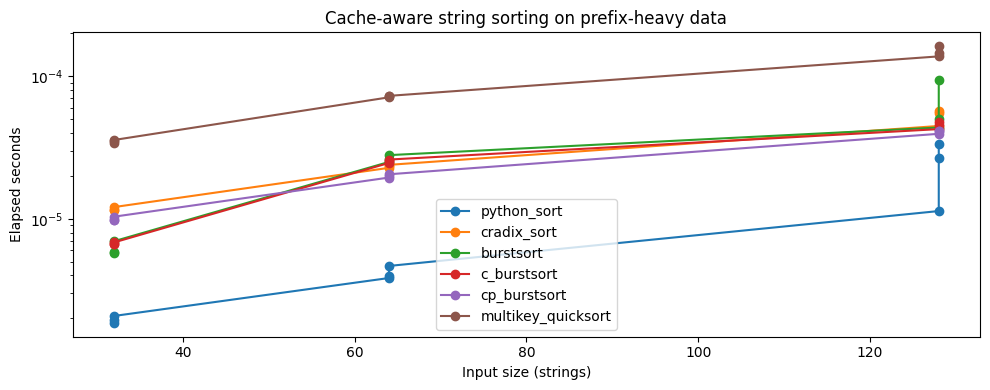

In [9]:
from collections import defaultdict

import matplotlib.pyplot as plt

summary_pairs = [
    (cast(str, row["algorithm"]), cast(float, row["mean_elapsed_seconds"]))
    for row in benchmark_summary
]
summary_pairs.sort(key=lambda pair: pair[1])
labels = [algorithm for algorithm, _ in summary_pairs]
means = [elapsed for _, elapsed in summary_pairs]

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(labels, means, color="#2f6f8f")
ax.set_title("Cache-aware string sorting: mean runtime by algorithm")
ax.set_ylabel("Mean elapsed seconds")
ax.set_yscale("log")
ax.tick_params(axis="x", rotation=30)
fig.tight_layout()
plt.show()

prefix_rows = [row for row in benchmark_rows if row["dataset"] == "prefix_heavy"]
trend_groups = defaultdict(list)
for row in prefix_rows:
    trend_groups[row["algorithm"]].append((row["count"], row["elapsed_seconds"]))

fig, ax = plt.subplots(figsize=(10, 4))
for algorithm_name in ["python_sort", "cradix_sort", "burstsort", "c_burstsort", "cp_burstsort", "multikey_quicksort"]:
    points = sorted(trend_groups.get(algorithm_name, []))
    if not points:
        continue
    counts = [count for count, _ in points]
    elapsed = [value for _, value in points]
    ax.plot(counts, elapsed, marker="o", label=algorithm_name)

ax.set_title("Cache-aware string sorting on prefix-heavy data")
ax.set_xlabel("Input size (strings)")
ax.set_ylabel("Elapsed seconds")
ax.set_yscale("log")
ax.legend(loc="best")
fig.tight_layout()
plt.show()
